In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [3]:
file_path = "../data/Overath/final_dataset.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Loaded Overath Data: {len(df)} rows")
except Exception as e:
    print(f"Error: {e}")
    df = pd.DataFrame()

Loaded Overath Data: 3676 rows


In [13]:
print(df.columns.tolist())

['binder_id', 'target_id', 'binder_chain', 'target_chains', 'target_chain_range', 'msa_info', 'binder', 'source', 'A_seq', 'A_length', 'B_seq', 'B_length', 'target_subchain_B_seq', 'target_subchain_B_len', 'target_subchain_C_seq', 'target_subchain_C_len', 'target_subchain_D_seq', 'target_subchain_D_len', 'af2_binder_aligned_rmsd', 'af2_pae_binder', 'af2_pae_interaction', 'af2_pae_target', 'af2_plddt_binder', 'af2_plddt_target', 'af2_plddt_total', 'af2_target_aligned_rmsd', 'af2_time', 'colab_actifptm_avg', 'colab_actifptm_std', 'colab_actifptm_model_0', 'colab_ptm_avg', 'colab_ptm_std', 'colab_ptm_model_0', 'colab_iptm_avg', 'colab_iptm_std', 'colab_iptm_model_0', 'boltz1_iptm_avg', 'boltz1_iptm_std', 'boltz1_iptm_model_0', 'boltz1_complex_plddt_avg', 'boltz1_complex_plddt_std', 'boltz1_complex_plddt_model_0', 'boltz1_complex_iplddt_avg', 'boltz1_complex_iplddt_std', 'boltz1_complex_iplddt_model_0', 'boltz1_complex_pde_avg', 'boltz1_complex_pde_std', 'boltz1_complex_pde_model_0', 'bolt

In [20]:
metrics = {
        'AF3 ipSAE (Proposed)':     'af3_ipSAE_min',           
        'AF3 pLDDT (Global)':       'af3_plddt_binder',        
        'AF2 pLDDT (Baseline)':     'af2_plddt_binder', 
        'Rosetta Energy (Physics)': 'af3_rosetta_binder_score',
        'AF3 pDockQ (Interface)':   'af3_pDockQ2_max'
}

target_col = 'binder'



Computing ROC curves for 5 metrics...


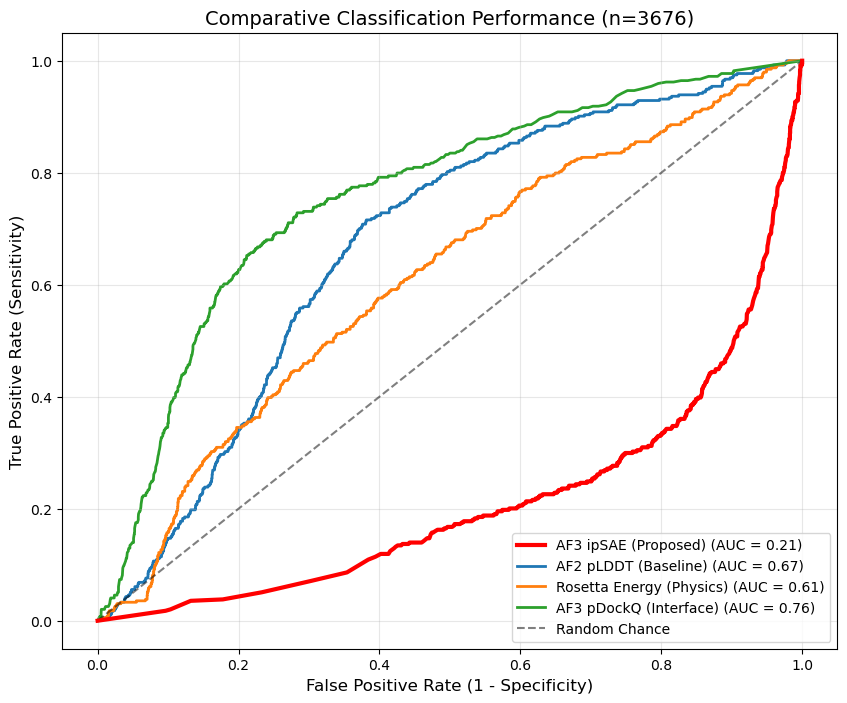

In [ ]:

plt.figure(figsize=(10, 8))
print(f"\nComputing ROC curves for {len(metrics)} metrics...")

for label, col in metrics.items():
    if col in df.columns:
            clean_data = df.dropna(subset=[col, target_col])
            
            y_true = clean_data[target_col].astype(int)
            y_score = clean_data[col]
            
            lower_is_better_keywords = ['ipsae', 'energy', 'score', 'rmsd', 'pae']
            
            if any(x in col.lower() for x in lower_is_better_keywords):
                 if 'plddt' not in col.lower() and 'pdockq' not in col.lower():
                    y_score = -y_score 

            fpr, tpr, _ = roc_curve(y_true, y_score)
            roc_auc = auc(fpr, tpr)
            

            if 'ipSAE' in label:
                color = 'red' 
                width = 3 
                zorder = 10
            else:
                color = None
                width = 2
                zorder = 1
            
            plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})', 
                     color=color, lw=width, zorder=zorder)


plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'Comparative Classification Performance (n={len(df)})', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
    
plt.show()



Computing ROC curves for 5 metrics...


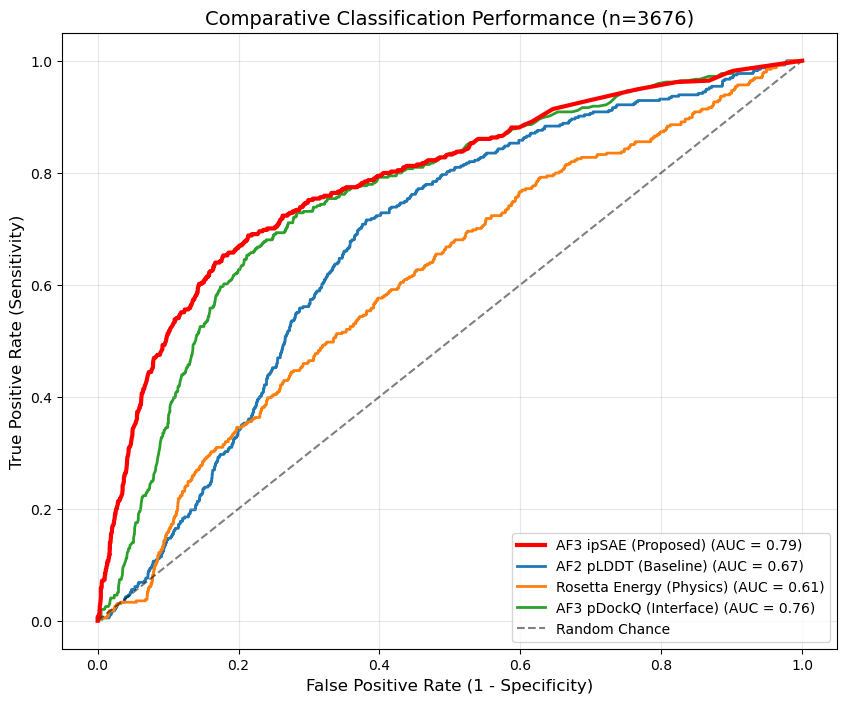

In [27]:
plt.figure(figsize=(10, 8))
print(f"\nComputing ROC curves for {len(metrics)} metrics...")

for label, col in metrics.items():
    if col in df.columns:
            # 1. Clean Data
            clean_data = df.dropna(subset=[col, target_col])
            
            y_true = clean_data[target_col].astype(int)
            y_score = clean_data[col]
            
            # 2. INTELLIGENT INVERSION LOGIC
            # We removed 'ipsae' from this list because your data showed Higher ipSAE = Binder.
            # We keep 'energy', 'score' (for Rosetta), 'rmsd', and 'pae'.
            lower_is_better_keywords = ['energy', 'score', 'rmsd', 'pae'] 
            
            if any(x in col.lower() for x in lower_is_better_keywords):
                 # Check exceptions: pLDDT, pDockQ, and ipSAE are "Higher is Better" -> Do NOT flip.
                 if 'plddt' not in col.lower() and 'pdockq' not in col.lower() and 'ipsae' not in col.lower():
                    y_score = -y_score 

            # 3. Calculate ROC
            fpr, tpr, _ = roc_curve(y_true, y_score)
            roc_auc = auc(fpr, tpr)
            
            # 4. Styling
            if 'ipSAE' in label:
                color = 'red' 
                width = 3 
                zorder = 10
            else:
                color = None
                width = 2
                zorder = 1
            
            plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})', 
                     color=color, lw=width, zorder=zorder)


plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'Comparative Classification Performance (n={len(df)})', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
    
plt.show()

In [ ]:
print("--- DEBUGGING TARGET COLUMN ---")
print("Original unique values in 'binder':", df['binder'].unique())
print("Data Type:", df['binder'].dtype)

df['binder_numeric'] = pd.to_numeric(df['binder'], errors='coerce')

if df['binder_numeric'].isna().sum() > len(df) * 0.5:
    print("Automatic conversion failed (too many NaNs). Trying string mapping...")
    mapping = {'True': 1, 'False': 0, 'Binder': 1, 'Non-Binder': 0, 'binder': 1, 'non_binder': 0}
    df['binder_numeric'] = df['binder'].map(mapping)

clean = df.dropna(subset=['af3_ipSAE_min', 'binder_numeric'])

y_true = clean['binder_numeric'].astype(int)
y_score = clean['af3_ipSAE_min']

print(f"\nAnalyzing {len(clean)} rows...")

raw_auc = roc_auc_score(y_true, y_score)

print("-" * 30)
print(f"Raw ipSAE AUC (Expect < 0.5 if lower is better): {raw_auc:.3f}")
print(f"Inverted ipSAE AUC (The true performance):       {1 - raw_auc:.3f}")
print("-" * 30)

--- DEBUGGING TARGET COLUMN ---
Original unique values in 'binder': [False True nan]
Data Type: object

Analyzing 3669 rows...
------------------------------
Raw ipSAE AUC (Expect < 0.5 if lower is better): 0.787
Inverted ipSAE AUC (The true performance):       0.213
------------------------------
